In [2]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.6 MB/s eta 0:00:00


/tmp/ipykernel_408/1999797409.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2010-01-01', progress=False)


Training Data Size (2010-2019): 2475 days.
Testing Data Size  (2021-Present): 1371 days. (2020 Skipped)

Training 3-State Gaussian Hidden Markov Model...

Executing Out-of-Sample Hybrid Backtest...

AAPL TRADING STRATEGY RESULTS
Just Holding AAPL (Return):      137.00%
Using Our Strategy (Return):     158.16%
--------------------------------------------------
Just Holding AAPL (Sharpe/Risk): 0.58
Using Our Strategy (Sharpe/Risk):1.17


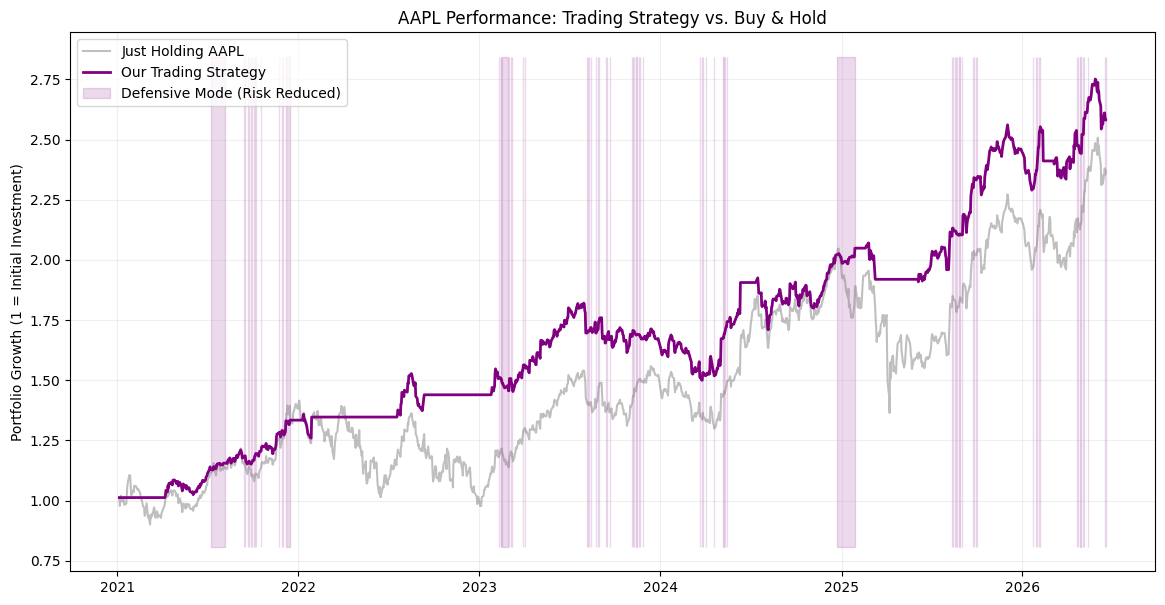

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn import hmm
from scipy.stats import norm
import matplotlib.pyplot as plt

print("Downloading AAPL Daily Data (2010 - Present)...")
df = yf.download('AAPL', start='2010-01-01', progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
df['Volatility'] = df['Returns'].rolling(window=21).std()

df['Z_Score'] = df['Returns'] / df['Volatility']
df['Buy_Factor'] = norm.cdf(df['Z_Score'])

df['V_Buy'] = df['Volume'] * df['Buy_Factor']
df['V_Sell'] = df['Volume'] * (1 - df['Buy_Factor'])

rolling_window = 21
df['Volume_Imbalance'] = (df['V_Buy'] - df['V_Sell']).abs()
df['VPIN'] = df['Volume_Imbalance'].rolling(window=rolling_window).sum() / df['Volume'].rolling(window=rolling_window).sum()

df.dropna(inplace=True)

X_train = df.loc[:'2019-12-31'][['Returns', 'Volatility']].values

#Out-of-sample testing window skips the 2020 anomaly
test_data = df.loc['2021-01-01':].copy()
X_test = test_data[['Returns', 'Volatility']].values

print(f"Training Data Size (2010-2019): {len(X_train)} days.")
print(f"Testing Data Size  (2021-Present): {len(X_test)} days. (2020 Skipped)")

#3 state HMM
print("\nTraining 3-State Gaussian Hidden Markov Model...")
model = hmm.GaussianHMM(n_components=3, covariance_type="diag", n_iter= 1000, tol = 100,  random_state=42)
model.fit(X_train)

# Sort unconstrained states by volatility
volatilities = model.means_[:, 1]
sorted_states = np.argsort(volatilities)

calm_state   = sorted_states[0]
chop_state   = sorted_states[1]
crisis_state = sorted_states[2]

print("\nExecuting Out-of-Sample Hybrid Backtest...")
test_data['Regime'] = model.predict(X_test)

# Base allocations from the HMM layers
test_data['HMM_Position'] = np.select(
    [
        test_data['Regime'] == calm_state,
        test_data['Regime'] == chop_state,
        test_data['Regime'] == crisis_state
    ],
    [1.0, 0.5, 0.0],
    default=0.0
)

# Hybrid Rules: Adjust allocation dynamically based on toxicity thresholds
hybrid_positions = []

for idx, row in test_data.iterrows():
    base_pos = row['HMM_Position']
    vpin_score = row['VPIN']
    regime = row['Regime']

    if regime == calm_state and vpin_score > 0.6:
        # High toxicity in a calm market -> cut to half
        final_pos = 0.5
    elif regime == chop_state and vpin_score > 0.55:
        # Toxicity rising during market chop signals -> exit
        final_pos = 0.0
    else:
        # Otherwise, maintain standard positioning
        final_pos = base_pos

    hybrid_positions.append(final_pos)

test_data['Target_Position'] = hybrid_positions

# 1- Day lag
test_data['Actual_Position'] = test_data['Target_Position'].shift(1)
test_data['Strategy_Returns'] = test_data['Actual_Position'] * test_data['Returns']
test_data.dropna(inplace=True)

# 5. PERFORMANCE REPORT & EQUITY CURVES
test_data['Buy_Hold_Cumulative'] = np.exp(test_data['Returns'].cumsum())
test_data['Strategy_Cumulative'] = np.exp(test_data['Strategy_Returns'].cumsum())

def calc_sharpe(returns):
    return (returns.mean() / returns.std()) * np.sqrt(252)

bh_return = (test_data['Buy_Hold_Cumulative'].iloc[-1] - 1) * 100
strat_return = (test_data['Strategy_Cumulative'].iloc[-1] - 1) * 100

bh_sharpe = calc_sharpe(test_data['Returns'])
strat_sharpe = calc_sharpe(test_data['Strategy_Returns'])

print("\n" + "="*50)
print("AAPL TRADING STRATEGY RESULTS")
print("="*50)
print(f"Just Holding AAPL (Return):      {bh_return:.2f}%")
print(f"Using Our Strategy (Return):     {strat_return:.2f}%")
print("-" * 50)
print(f"Just Holding AAPL (Sharpe/Risk): {bh_sharpe:.2f}")
print(f"Using Our Strategy (Sharpe/Risk):{strat_sharpe:.2f}")
print("="*50)

# Render Equity Chart
plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data['Buy_Hold_Cumulative'], label='Just Holding AAPL', color='grey', alpha=0.5)
plt.plot(test_data.index, test_data['Strategy_Cumulative'], label='Our Trading Strategy', color='purple', linewidth=2)

# Overlay background shading where the strategy successfully forced a defensive downshift
vpin_active_mask = test_data['Actual_Position'] < test_data['HMM_Position'].shift(1)
plt.fill_between(test_data.index, plt.gca().get_ylim()[0], plt.gca().get_ylim()[1],
                 where=vpin_active_mask, color='purple', alpha=0.15, label='Defensive Mode (Risk Reduced)')

plt.title('AAPL Performance: Trading Strategy vs. Buy & Hold')
plt.ylabel('Portfolio Growth (1 = Initial Investment)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()